In [ ]:
# SETUP
# 1. insightface d'abord (il installe onnxruntime CPU au passage, tant pis)
!pip install insightface
# 2. on retire TOUTE trace d'onnxruntime (CPU et GPU)
!pip uninstall -y onnxruntime onnxruntime-gpu
# 3. la version GPU en DERNIER : c'est elle qui possède le module désormais
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 95.4 MB/s eta 0:00:00
Found existing installation: onnxruntime 1.27.0
Uninstalling onnxruntime-1.27.0:
  Successfully uninstalled onnxruntime-1.27.0
Found existing installation: onnxruntime-gpu 1.22.0
Uninstalling onnxruntime-gpu-1.22.0:
  Successfully uninstalled onnxruntime-gpu-1.22.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 5.3 MB/s eta 0:00:00


In [3]:
!pip uninstall -y onnxruntime onnxruntime-gpu
!pip install onnxruntime-gpu==1.22.0

Found existing installation: onnxruntime-gpu 1.27.0
Uninstalling onnxruntime-gpu-1.27.0:
  Successfully uninstalled onnxruntime-gpu-1.27.0
  Using cached onnxruntime_gpu-1.22.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.1 kB)
Using cached onnxruntime_gpu-1.22.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (283.2 MB)


In [4]:
import onnxruntime as ort
print(ort.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [5]:
# Chargement du modèle et première fonction métier
import cv2
import numpy as np
from insightface.app import FaceAnalysis

# on precise name="buffalo_l" pour que le notebook sache sur quel modele
#documenter et pas le default
app = FaceAnalysis(name="buffalo_l",
                   providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))#index 0 pour gpu
#le size pour adapter la taille de l'image car l'ia possede un equation math fixe
#et Pour faire ses calculs, elle exige que toutes les images d'entrée aient
#exactement la même taille de grille de pixels

def get_embedding(img_bgr):
    #Prend une image (format BGR d'OpenCV), retourne l'embedding 512-d
    #du visage le plus grand, ou None si aucun visage détecté.
    faces = app.get(img_bgr)
    if len(faces) == 0:
        return None
    # S'il y a plusieurs visages, on prend le plus grand (le plus proche de la caméra)
    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]))
    return face.normed_embedding

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 97458.90KB/s] 


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [ ]:
# Auth Kaggle + téléchargement LFW
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_835865bbae8f05cc325ab727a4ab0942"

!mkdir -p ~/.kaggle && echo "KGAT_835865bbae8f05cc325ab727a4ab0942" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token #made my token expired vu que c'est publié sur github

!kaggle datasets download -d jessicali9530/lfw-dataset -p /content/lfw --unzip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:00<00:00, 142MB/s]



In [ ]:
# Extraction des embeddings d'un sous-ensemble de LFW
import os, glob
from tqdm import tqdm   # barre de progression

DATA_DIR = "/content/lfw/lfw-deepfunneled/lfw-deepfunneled"
MIN_IMAGES = 20   #personnes ayant >= 20 photos, parfait pour couper en train/test
MAX_PER_PERSON = 30  # plafond pour équilibrer le dataset et eviter le desequilibre de classes

# 1. Sélection des personnes avec assez d'images(20 min et 30 max par personne)
people = []
for name in sorted(os.listdir(DATA_DIR)):
    imgs = glob.glob(os.path.join(DATA_DIR, name, "*.jpg"))
    if len(imgs) >= MIN_IMAGES:
        people.append((name, imgs[:MAX_PER_PERSON]))
print(f"{len(people)} personnes retenues")

# 2. Extraction : chaque image -> embedding 512-d via buffalo_l
X, y = [], []   # X = embeddings, y = étiquettes (noms)
skipped = 0
for name, imgs in tqdm(people):
    for path in imgs:
        img = cv2.imread(path)          # lit en BGR, ce qu'attend InsightFace
        emb = get_embedding(img)        # notre fonction de la cellule 2
        if emb is None:                 # aucun visage détecté
            skipped += 1
            continue
        X.append(emb)
        y.append(name)
#l'utilisation e scikit-learn de l'etape suivante attend le format(x,512)matrice etc
X = np.array(X)#conversion en tableau numpy(bloc memoire en forme de matrice)
y = np.array(y)
print(f"Embeddings extraits : {X.shape}, images sans visage détecté : {skipped}")

62 personnes retenues


100%|██████████| 62/62 [01:06<00:00,  1.06s/it]

Embeddings extraits : (1668, 512), images sans visage détecté : 5


In [ ]:
# Entraînement du classifieur sur les embeddings
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Découpage train/test : 80% pour train, 20% pour test
# (stratify=y : garde la même proportion de chaque personne des deux côtés)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# SVM linéaire : cherche les frontières qui séparent les personnes
# dans l'espace 512-d. probability=True pour obtenir un score de confiance.
clf = SVC(kernel="linear", probability=True)
clf.fit(X_train, y_train)

#Évaluation sur les 20% jamais vus pendant l'entraînement
y_pred = clf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")

Accuracy : 0.9940


In [ ]:
#Sauvegarde du classifieur entraîné
import joblib
joblib.dump(clf, "/content/classifier_svm.joblib")
print("Modèle sauvegardé.")

Modèle sauvegardé.


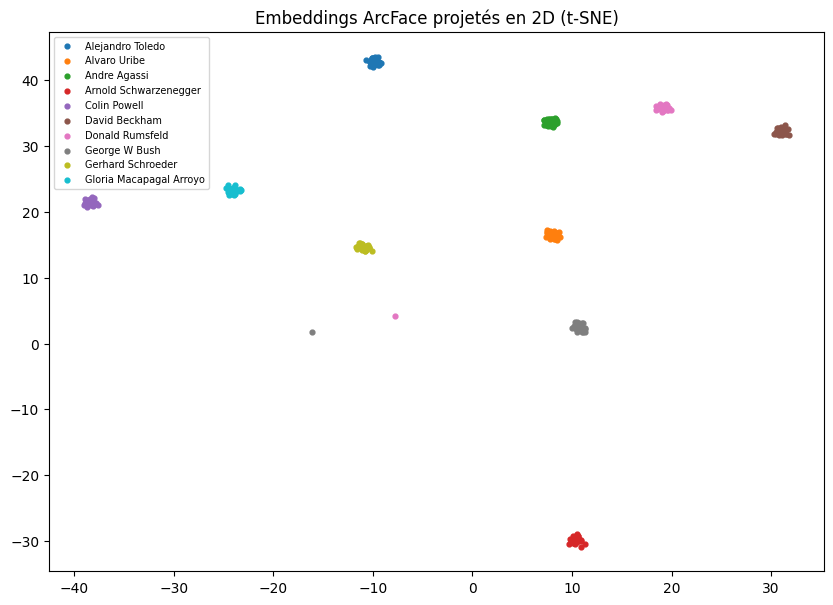

In [ ]:
#Visualisation des nuages d'embeddings (t-SNE)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# On projette 512-d -> 2D (calcul ~1 min)
X_2d = TSNE(n_components=2, random_state=42).fit_transform(X)

# On colore les 10 personnes les plus représentées, pour la lisibilité
from collections import Counter
top10 = [n for n, _ in Counter(y).most_common(10)]
plt.figure(figsize=(10, 7))
for name in top10:
    pts = X_2d[y == name]
    plt.scatter(pts[:, 0], pts[:, 1], s=12, label=name.replace("_", " "))
plt.legend(fontsize=7); plt.title("Embeddings ArcFace projetés en 2D (t-SNE)")
plt.savefig("/content/tsne_embeddings.png", dpi=150)
plt.show()

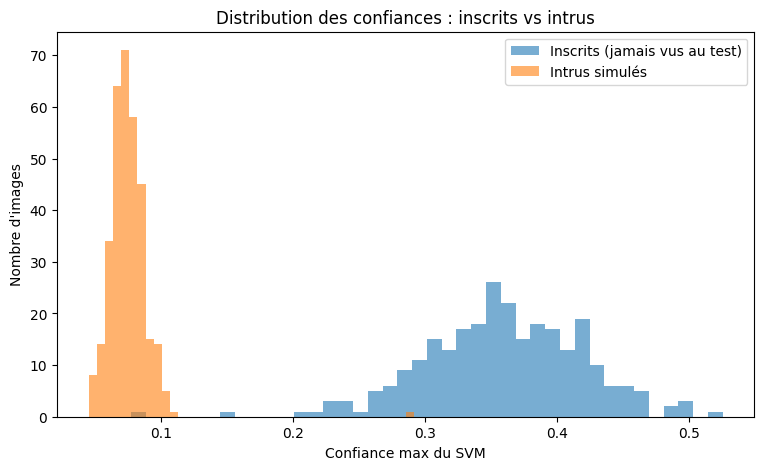

Confiance médiane inscrits : 0.359
Confiance médiane intrus   : 0.074


In [ ]:
# cellule 7: Détermination expérimentale du seuil "inconnu"
# Idée : 12 personnes jouent les intrus, le SVM est réentraîné sans elles.

#Séparation connus / "intrus"
names = sorted(set(y))
known_names   = names[:50]   # le système ne connaît qu'eux
intrus_names  = names[50:]   # jamais vus par le SVM = intrus simulés

#façon numpy d efiltrer sans boucle
mask_known  = np.isin(y, known_names)#produit un tableau de 1668 booleans=true
#si le nom de la photo i est dans les 50 connus et =false sinon, on garde juste les true
mask_intrus = ~mask_known#l'inverse de mask_known

#Réentraînement sur les connus uniquement (mêmes réglages que cellule 5)
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X[mask_known], y[mask_known], test_size=0.2,
    stratify=y[mask_known], random_state=42)

clf2 = SVC(kernel="linear", probability=True)#cree un objet neuf
clf2.fit(Xk_train, yk_train)

#Confiance max du SVM sur chaque groupe
#predict_proba renvoie 50 probas par image ; .max() = la plus haute
conf_known  = clf2.predict_proba(Xk_test).max(axis=1)          # vrais inscrits
conf_intrus = clf2.predict_proba(X[mask_intrus]).max(axis=1)   # intrus

#Visualisation : deux histogrammes superposés
plt.figure(figsize=(9, 5))
plt.hist(conf_known,  bins=40, alpha=0.6, label="Inscrits (jamais vus au test)")
plt.hist(conf_intrus, bins=40, alpha=0.6, label="Intrus simulés")
plt.xlabel("Confiance max du SVM"); plt.ylabel("Nombre d'images")
plt.legend(); plt.title("Distribution des confiances : inscrits vs intrus")
plt.savefig("/content/seuil_confiances.png", dpi=150)
plt.show()

print("Confiance médiane inscrits :", np.median(conf_known).round(3))
print("Confiance médiane intrus   :", np.median(conf_intrus).round(3))

In [ ]:
#Prédiction avec rejet des inconnus + sauvegarde
SEUIL = 0.15  # choisi expérimentalement (cf. histogramme cellule 7)

def predict_identity(embedding):
    probas = clf.predict_proba([embedding])[0]
    if probas.max() < SEUIL:
        return "inconnu", float(probas.max())
    return clf.classes_[probas.argmax()], float(probas.max())

import joblib
joblib.dump(clf, "/content/classifier_svm.joblib")
print("OK — modèle + seuil prêts")

OK — modèle + seuil prêts


In [ ]:
# CELLULE 7b: FAR et FRR pour plusieurs seuils candidats
for s in [0.12, 0.15, 0.19, 0.20, 0.25]:
    far = (conf_intrus >= s).mean()   # % d'intrus acceptés à tort
    frr = (conf_known  <  s).mean()   # % d'inscrits rejetés à tort
    print(f"seuil {s:.2f} -> FAR {far:.1%} | FRR {frr:.1%}")

seuil 0.12 -> FAR 0.3% | FRR 0.4%
seuil 0.15 -> FAR 0.3% | FRR 0.4%
seuil 0.19 -> FAR 0.3% | FRR 0.7%
seuil 0.20 -> FAR 0.3% | FRR 0.7%
seuil 0.25 -> FAR 0.3% | FRR 3.7%
